<a href="https://colab.research.google.com/github/yesahek/Machine_Learning/blob/main/Deep%20Learning/PyTorch_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# check PyTorch version
torch.__version__

'2.11.0+cpu'

## 1. Data (preparing and loading)
Data can be almost anything

Machin learning is a game of two parts:
1. Get data into a numberical repressentaion.
2. Build a model to learn patterns in that numberical representaiton.





In [ ]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X+bias
X[:10], y[:10], len(X)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50)

In [ ]:
# Spliting data into training and test sets

In [ ]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test),len(y_test)

(40, 40, 10, 10)

In [ ]:
def plot_predictions(train_data=X_train, train_labels=y_train,test_data=X_test,test_labels=y_test,predictions=None):
  """
  Plots traing data, test data and compares predictions.
  """
  plt.figure(figsize=(10,7))

  # plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  #Are there predicion?
  if predictions is not None:
    #plot the predictions if they exist
    plt.scatter(test_data, predictions, c="r",s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size":14});


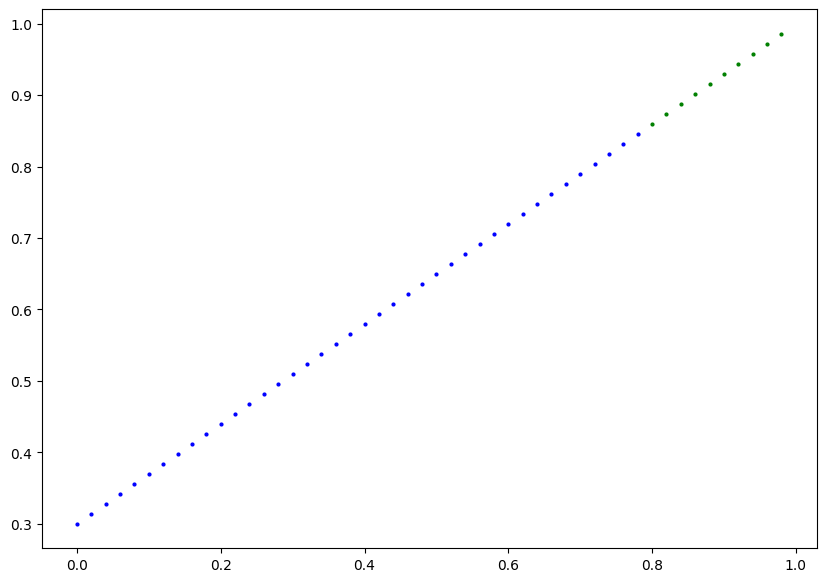

In [ ]:
plot_predictions();

# Build Model

In [ ]:
# Create linear regression model class
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,requires_grad=True, dtype=torch.float))

  # Forward method to define the computation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias



In [ ]:
#Create a Random seed
torch.manual_seed(42)
model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
# Making prediction using `torch.inference_mode()`
 # Make Predictions with model
with torch.inference_mode():
  y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

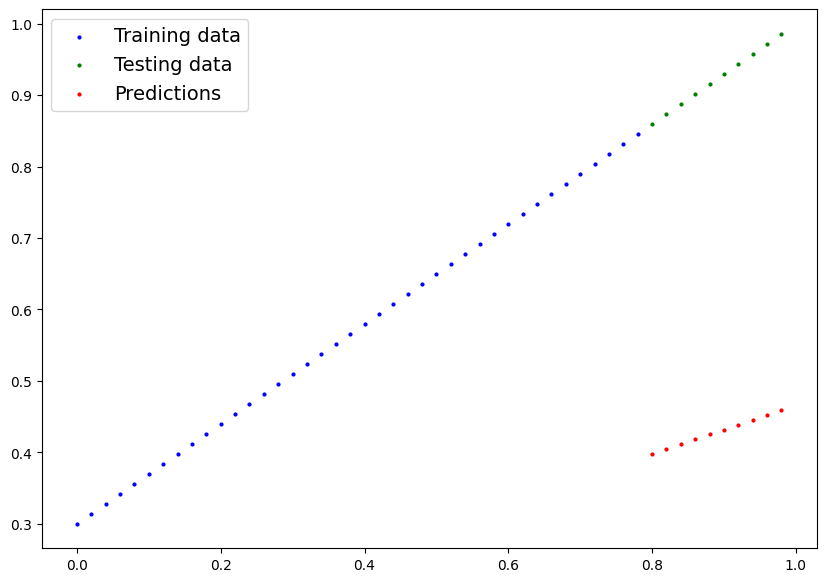

In [ ]:
plot_predictions(predictions=y_preds)

In [ ]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.01)

In [ ]:
### Building a training loop in pytorch

epches = 100

### Training
# Loop through the data
for epoch in range(epches):
  model_0.train()
  # 1. forward pass
  y_pred = model_0(X_train)
  # 2. calculate the loss
  loss = loss_fn(y_pred,y_train)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. perform backpropgation on the loss with respect to the parameters
  loss.backward()
  # 5. Step the optimizer (perform gradient descent)
  optimizer.step()
  ### Testing
  model_0.eval()
  with torch.inference_mode():
    # 1. Do the forward pass
    test_pred = model_0(X_test)

    # 2. Calculate the loss
    test_loss = loss_fn(test_pred, y_test)

    # Print out what's happenin
    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")
      # print out model state_dict()
      print(model_0.state_dict())

Epoch: 0 | Loss: 0.024458957836031914 | Test loss: 0.05646304413676262
OrderedDict({'weights': tensor([0.5800]), 'bias': tensor([0.3503])})
Epoch: 10 | Loss: 0.021020207554101944 | Test loss: 0.04819049686193466
OrderedDict({'weights': tensor([0.5972]), 'bias': tensor([0.3433])})
Epoch: 20 | Loss: 0.01758546568453312 | Test loss: 0.04060482233762741
OrderedDict({'weights': tensor([0.6141]), 'bias': tensor([0.3358])})
Epoch: 30 | Loss: 0.014155393466353416 | Test loss: 0.03233227878808975
OrderedDict({'weights': tensor([0.6313]), 'bias': tensor([0.3288])})
Epoch: 40 | Loss: 0.010716589167714119 | Test loss: 0.024059748277068138
OrderedDict({'weights': tensor([0.6485]), 'bias': tensor([0.3218])})
Epoch: 50 | Loss: 0.0072835334576666355 | Test loss: 0.016474086791276932
OrderedDict({'weights': tensor([0.6654]), 'bias': tensor([0.3143])})
Epoch: 60 | Loss: 0.0038517764769494534 | Test loss: 0.008201557211577892
OrderedDict({'weights': tensor([0.6826]), 'bias': tensor([0.3073])})
Epoch: 70 

In [ ]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

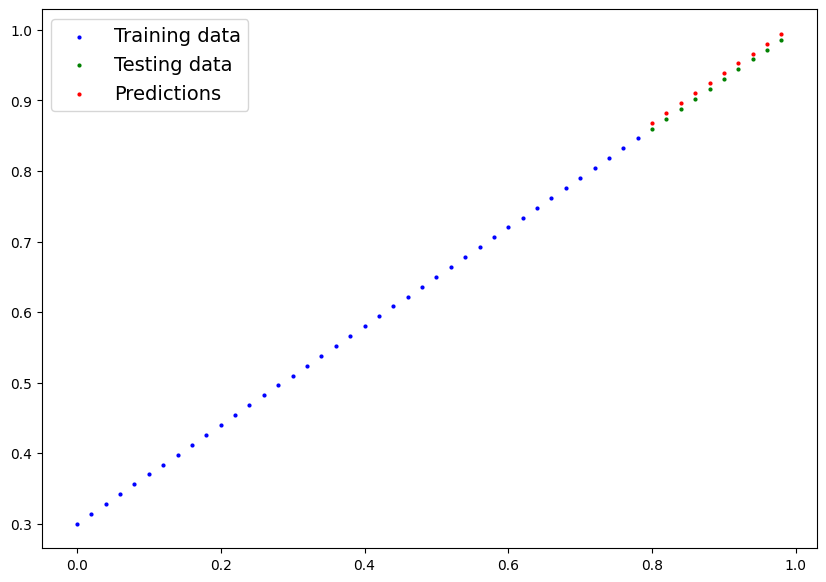

In [ ]:
plot_predictions(predictions=y_preds_new)